# Fertilizer Classification — Improved Notebook

This notebook is an improved, step-by-step version of your original `Fertilizer.ipynb`.
It adds robust preprocessing, a stronger neural network architecture, useful callbacks, training visualization, evaluation, and tips to further improve accuracy and reduce loss.

Run each cell in order. Cells that install packages are optional — run them if you get `ModuleNotFoundError` locally.


In [ ]:
# Optional: install packages if missing (run in your terminal or in a notebook cell with !)
# Uncomment and run only if you need to install locally.
# !pip install seaborn
# !pip install tensorflow scikit-learn pandas numpy matplotlib


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
print('Imports done')


Imports done


In [17]:
import sys, tensorflow as tf
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Matplotlib:', plt.matplotlib.__version__)
print('TensorFlow:', tf.__version__)


Python: 3.13.7
NumPy: 2.2.6
Pandas: 2.3.2
Matplotlib: 3.10.6
TensorFlow: 2.20.0


In [18]:
# Load dataset (ensure 'fertilizer.csv' is in the same folder)
df = pd.read_csv('fertilizer.csv')
print('Dataset loaded. Shape:', df.shape)
df.head()


Dataset loaded. Shape: (205, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [19]:
# Basic checks
print('Missing values per column:\n', df.isnull().sum())
print('\nUnique counts per column:\n', df.nunique())
print('\nTarget distribution:')
print(df['Fertilizer Name'].value_counts())


Missing values per column:
 Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

Unique counts per column:
 Temparature        14
Humidity           13
Moisture           41
Soil Type           5
Crop Type          11
Nitrogen           24
Potassium          13
Phosphorous        32
Fertilizer Name     7
dtype: int64

Target distribution:
Fertilizer Name
Urea        44
DAP         38
28-28       36
20-20       30
14-35-14    29
17-17-17    18
10-26-26    10
Name: count, dtype: int64


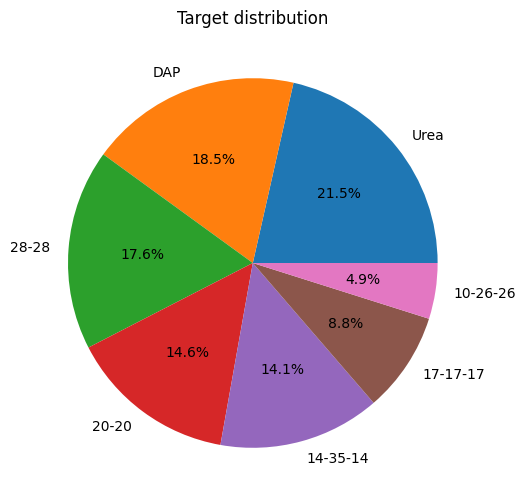

In [20]:
# Simple pie chart for target distribution (matplotlib)
labels = df['Fertilizer Name'].value_counts().index.tolist()
counts = df['Fertilizer Name'].value_counts().values
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=labels, autopct='%1.1f%%')
ax.set_title('Target distribution')
plt.show()


In [21]:
# Encode target labels
label_encoder = LabelEncoder()
df['Fertilizer Name_enc'] = label_encoder.fit_transform(df['Fertilizer Name'])
target_names = list(label_encoder.classes_)
print('Classes (encoded):', {i:n for i,n in enumerate(target_names)})

# Features and target
X = df.drop(['Fertilizer Name', 'Fertilizer Name_enc'], axis=1)
Y = df['Fertilizer Name_enc']
print('X shape:', X.shape, 'Y shape:', Y.shape)


Classes (encoded): {0: '10-26-26', 1: '14-35-14', 2: '17-17-17', 3: '20-20', 4: '28-28', 5: 'DAP', 6: 'Urea'}
X shape: (205, 8) Y shape: (205,)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

# 1) Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# 2) Stratified split
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42, stratify=Y
)

# 3) Scale features
scaler = StandardScaler()
x_train_n = scaler.fit_transform(x_train)
x_test_n = scaler.transform(x_test)

# 4) One-hot encode targets
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# 5) Class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_arr))

print('num_classes =', num_classes)
print('x_train_n shape =', x_train_n.shape)
print('y_train_cat shape =', y_train_cat.shape)
print('class_weights =', class_weights)


num_classes = 7
x_train_n shape = (164, 20)
y_train_cat shape = (164, 7)
class_weights = {0: np.float64(2.9285714285714284), 1: np.float64(1.0186335403726707), 2: np.float64(1.6734693877551021), 3: np.float64(0.9761904761904762), 4: np.float64(0.8078817733990148), 5: np.float64(0.7557603686635944), 6: np.float64(0.6693877551020408)}


In [23]:
# Build a deeper model with BatchNorm and Dropout
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train_n.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\karth\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,151 (55.28 KB)

 Trainable params: 13,703 (53.53 KB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
# Callbacks: save best model, early stopping and reduce LR on plateau
model_name = 'best_weights.h5'
checkpoint = ModelCheckpoint(model_name, monitor='val_loss', mode='min', save_best_only=True, verbose=1)
earlystopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

callbacks = [checkpoint, earlystopping, reduce_lr]


In [25]:
# Training: include class weights and validation split
history = model.fit(
    x_train_n, y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.1875 - loss: 3.3244
Epoch 1: val_loss improved from None to 2.06683, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.2061 - loss: 2.4227 - val_accuracy: 0.0606 - val_loss: 2.0668 - learning_rate: 0.0010
Epoch 2/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2188 - loss: 2.3272
Epoch 2: val_loss improved from 2.06683 to 2.01749, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2595 - loss: 2.1043 - val_accuracy: 0.0909 - val_loss: 2.0175 - learning_rate: 0.0010
Epoch 3/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1250 - loss: 2.1433
Epoch 3: val_loss improved from 2.01749 to 1.98381, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1603 - loss: 2.4302 - val_accuracy: 0.0909 - val_loss: 1.9838 - learning_rate: 0.0010
Epoch 4/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3750 - loss: 1.7023
Epoch 4: val_loss improved from 1.98381 to 1.95043, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2901 - loss: 1.9066 - val_accuracy: 0.1515 - val_loss: 1.9504 - learning_rate: 0.0010
Epoch 5/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3125 - loss: 1.8374
Epoch 5: val_loss improved from 1.95043 to 1.91782, saving model to best_weights.h5


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7557 - loss: 0.6314 - val_accuracy: 0.7273 - val_loss: 0.7479 - learning_rate: 0.0010
Epoch 67/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8438 - loss: 0.5589
Epoch 67: val_loss improved from 0.74788 to 0.74218, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7557 - loss: 0.6773 - val_accuracy: 0.7273 - val_loss: 0.7422 - learning_rate: 0.0010
Epoch 68/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8125 - loss: 0.4807
Epoch 68: val_loss improved from 0.74218 to 0.73890, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8015 - loss: 0.6220 - val_accuracy: 0.7273 - val_loss: 0.7389 - learning_rate: 0.0010
Epoch 69/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8125 - loss: 0.5399
Epoch 69: val_loss improved from 0.73890 to 0.73707, saving model to best_weights.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8092 - loss: 0.6101 - val_accuracy: 0.7273 - val_loss: 0.7371 - learning_rate: 0.0010
Epoch 70/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8750 - loss: 0.5136
Epoch 70: val_loss did not improve from 0.73707
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8321 - loss: 0.5720 - val_accuracy: 0.7273 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 71/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9688 - loss: 0.3967
Epoch 71: val_loss did not improve from 0.73707
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8702 - loss: 0.4485 - val_accuracy: 0.7273 - val_loss: 0.7398 - learning_rate: 0.0010
Epoch 72/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7812 - loss: 0.7143
Epoch 72: val_loss did not improve from 0.73707
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8473 - loss: 0.5196 - val_accuracy: 0.7273 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 73/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/ste

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7710 - loss: 0.6561 - val_accuracy: 0.7273 - val_loss: 0.7326 - learning_rate: 0.0010
Epoch 74/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8750 - loss: 0.5522
Epoch 74: val_loss did not improve from 0.73261
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8779 - loss: 0.4694 - val_accuracy: 0.7273 - val_loss: 0.7408 - learning_rate: 0.0010
Epoch 75/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7812 - loss: 0.5912
Epoch 75: val_loss did not improve from 0.73261
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8015 - loss: 0.5437 - val_accuracy: 0.7273 - val_loss: 0.7398 - learning_rate: 0.0010
Epoch 76/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7812 - loss: 0.6491
Epoch 76: val_loss did not improve from 0.73261
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8092 - loss: 0.6688 - val_accuracy: 0.7273 - val_loss: 0.7420 - learning_rate: 0.0010
Epoch 77/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/ste

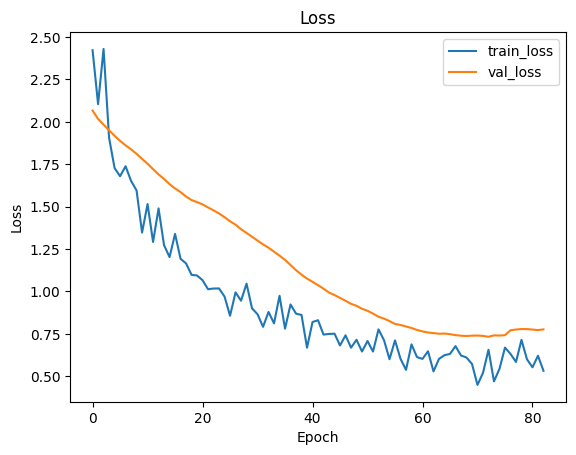

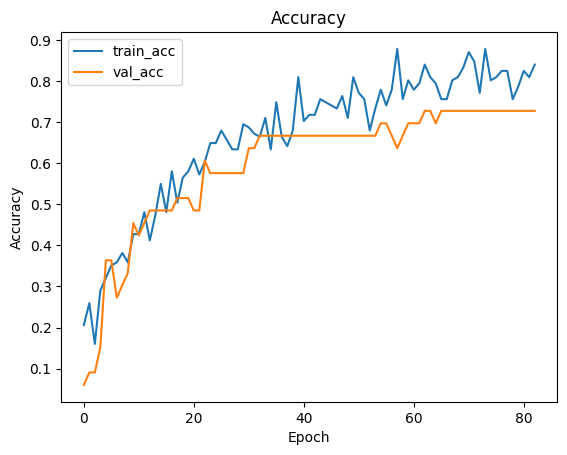

In [26]:
# Plot training and validation loss / accuracy using matplotlib
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [27]:
# Evaluate on test set
loss, accuracy = model.evaluate(x_test_n, y_test_cat, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

# Predictions (class indices)
pred_probs = model.predict(x_test_n)
preds = np.argmax(pred_probs, axis=1)

print('\nClassification Report:')
print(classification_report(y_test, preds, target_names=target_names))

cm = confusion_matrix(y_test, preds)
print('Confusion Matrix:\n', cm)


Test loss: 0.5701881051063538
Test accuracy: 0.8048780560493469
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step

Classification Report:
              precision    recall  f1-score   support

    10-26-26       0.67      1.00      0.80         2
    14-35-14       0.62      0.83      0.71         6
    17-17-17       0.75      0.75      0.75         4
       20-20       1.00      0.67      0.80         6
       28-28       0.70      1.00      0.82         7
         DAP       1.00      0.57      0.73         7
        Urea       1.00      0.89      0.94         9

    accuracy                           0.80        41
   macro avg       0.82      0.82      0.79        41
weighted avg       0.85      0.80      0.81        41

Confusion Matrix:
 [[2 0 0 0 0 0 0]
 [0 5 1 0 0 0 0]
 [1 0 3 0 0 0 0]
 [0 1 0 4 1 0 0]
 [0 0 0 0 7 0 0]
 [0 2 0 0 1 4 0]
 [0 0 0 0 1 0 8]]


In [29]:
# Save the full model for later use
# model.save('fertilizer_model.h5')
# print('Saved model to fertilizer_model.h5')
import joblib

# Save the model object as a joblib file
joblib.dump(model, 'model_joblib.pkl')
joblib.dump(model, 'ferti.joblib')

['ferti.joblib']

In [30]:
# Get predicted probabilities
y_pred_proba = model.predict(x_test_n)

# Convert to class labels
y_pred = np.argmax(y_pred_proba, axis=1)

print("Sample Predictions:", y_pred[:10])
print("True Labels      :", y_test[:10].tolist())


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Sample Predictions: [5 1 6 4 2 0 1 4 1 1]
True Labels      : [5, 5, 6, 4, 1, 2, 3, 4, 1, 1]


## Tips & Next Steps
- If you still see high variance (training >> validation accuracy), increase dropout, add L2 regularization or reduce network size.
- If you see underfitting, increase model capacity (more neurons/layers) or train longer.
- Try `class_weight` (already included) or oversampling (SMOTE) if classes are imbalanced.
- Use `GridSearchCV` or Keras Tuner to find optimum hyperparameters (learning rate, batch size, layer sizes).
- If features are categorical, consider one-hot encoding or embedding layers.
- For reproducibility set random seeds: `np.random.seed(...)`, `tf.random.set_seed(...)`.


In [17]:
y_pred_proba = model.predict(x_test_n)       # probabilities
y_pred = np.argmax(y_pred_proba, axis=1)     # numeric labels

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [15]:
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("Sample Predictions:", y_pred_labels[:10])
print("True Labels      :", label_encoder.inverse_transform(y_test[:10]))

Sample Predictions: ['DAP' 'DAP' 'Urea' '28-28' '17-17-17' '10-26-26' '14-35-14' 'DAP'
 '14-35-14' '14-35-14']
True Labels      : ['DAP' 'DAP' 'Urea' '28-28' '14-35-14' '17-17-17' '20-20' '28-28'
 '14-35-14' '14-35-14']


In [24]:
import pandas as pd
import numpy as np

# 👇 ask user for values
temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
moisture = float(input("Enter Moisture: "))
nitrogen = float(input("Enter Nitrogen: "))
phosphorus = float(input("Enter Phosphorus: "))
potassium = float(input("Enter Potassium: "))
ph = float(input("Enter pH value: "))
rainfall = float(input("Enter Rainfall: "))

# soil type (choose one)
soil_type = input("Enter Soil Type (Sandy/Clay/Loamy): ")
# crop type (choose one)
crop_type = input("Enter Crop Type (Rice/Wheat/etc.): ")

# 👇 create input dict with dummy variables
new_input = {
    "Temperature": temperature,
    "Humidity": humidity,
    "Moisture": moisture,
    "Nitrogen": nitrogen,
    "Phosphorus": phosphorus,
    "Potassium": potassium
}

# handle soil type dummy encoding
new_input["Soil_Type_Sandy"] = 1 if soil_type.lower() == "sandy" else 0
new_input["Soil_Type_Clay"] = 1 if soil_type.lower() == "clay" else 0
new_input["Soil_Type_Loamy"] = 1 if soil_type.lower() == "loamy" else 0

# handle crop type dummy encoding (extend this as per your dataset)
new_input["Crop_Type_Rice"] = 1 if crop_type.lower() == "rice" else 0
new_input["Crop_Type_Wheat"] = 1 if crop_type.lower() == "wheat" else 0
# add more crop dummies if needed

# 👇 convert to DataFrame and align with training columns
new_input_df = pd.DataFrame([new_input])
new_input_df = new_input_df.reindex(columns=x_train.columns, fill_value=0)

# 👇 scale
new_input_scaled = scaler.transform(new_input_df)

# 👇 predict
prediction_proba = model.predict(new_input_scaled)
prediction_index = np.argmax(prediction_proba, axis=1)
predicted_fertilizer = label_encoder.inverse_transform(prediction_index)

print("✅ Predicted Fertilizer:", predicted_fertilizer[0])


Enter Temperature:  20
Enter Humidity:  83
Enter Moisture:  26
Enter Nitrogen:  80
Enter Phosphorus:  40
Enter Potassium:  60
Enter Soil Type (Sandy/Clay/Loamy):  Clay
Enter Crop Type (Rice/Wheat/etc.):  Rice


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
✅ Predicted Fertilizer: 10-26-26
